# One-DTE Volatility Strategy — Results

A daily signed volatility trade on SPXW one-day-to-expiration options: a reversal signal
on the straddle's own recent short-side returns sizes the book long or short at each
close; long days buy an iron butterfly, short days sell a 15Δ strangle; positions ride
one session to PM settlement. Two production position rules (a signal deadband and a
weekend adjustment) and the live loss rule (buy the short package back if it marks at 3×
the credit) are all measured here — the loss rule with 5-minute intraday marks.

*Backtest 2023-01 → 2026-08 on exchange close marks; the strategy has traded live for
about a year and the realized Sharpe (~2.3–2.4) has tracked the backtest. Enough is shown
to evaluate the strategy; the signal parameters and research stack stay private.*

In [1]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import datetime
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

D = Path('data')
bt = pl.read_parquet(D/'backtest_daily.parquet').sort('tradingDate')
sx = pl.read_parquet(D/'stop3x_daily.parquet').sort('entry_date')
desk = bt.filter(pl.col('book')=='desk_ironfly_strangle')
ref = bt.filter(pl.col('book')=='ref_straddle')

def sh(x, ann=252):
    x = np.asarray(x, float); x = x[~np.isnan(x)]
    return float(x.mean()/x.std()*np.sqrt(ann))

print(f"daily panel {desk['tradingDate'].min()} -> {desk['tradingDate'].max()} "
      f"({desk.height} sessions)")
pl.Config.set_tbl_cols(-1); pl.Config.set_tbl_width_chars(200)
pl.Config.set_tbl_hide_dataframe_shape(True)
plt.rcParams.update({'figure.dpi': 96, 'axes.grid': True, 'grid.alpha': 0.25,
                     'axes.spines.top': False, 'axes.spines.right': False})

daily panel 2023-01-03 -> 2026-08-31 (938 sessions)


## 1. The strategy in one table

| | |
|---|---|
| Signal | weighted reversal on the 1-DTE straddle's recent short-side returns, demeaned, clipped |
| Long days (signal > 0) | buy the iron butterfly (ATM straddle − 15Δ strangle) |
| Short days (signal < 0) | sell the 15Δ strangle |
| Rules | \|signal\| ≤ 0.10 → flat · holding > 1 calendar day → longs 0, shorts ×1.5 |
| Loss rule (live) | short package marks at **3× credit** → buy it back (intraday) |
| Exit | PM settlement — the day-1 close and cash settlement coincide on SPXW dailies |
| Sizing | linear in the signal, fixed units per 1.00 signal |

## 2. Performance — both configurations, rules on vs off (identical inputs)

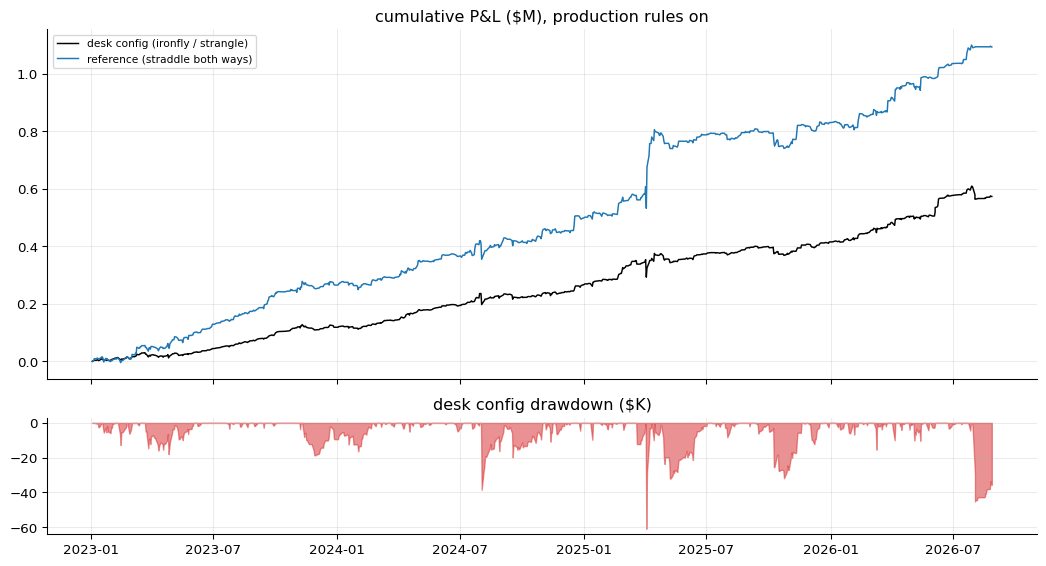

┌───────────┬────────────┬─────┬────────┬──────┬─────────┬─────┬─────────┬───────┬──────┐
│ config    ┆ arm        ┆ n   ┆ sharpe ┆ mean ┆ total_K ┆ hit ┆ worst_K ┆ skew  ┆ kurt │
│ ---       ┆ ---        ┆ --- ┆ ---    ┆ ---  ┆ ---     ┆ --- ┆ ---     ┆ ---   ┆ ---  │
│ str       ┆ str        ┆ i64 ┆ f64    ┆ i64  ┆ i64     ┆ str ┆ i64     ┆ f64   ┆ f64  │
╞═══════════╪════════════╪═════╪════════╪══════╪═════════╪═════╪═════════╪═══════╪══════╡
│ desk      ┆ pre_rules  ┆ 917 ┆ 2.05   ┆ 557  ┆ 511     ┆ 68% ┆ -61     ┆ -3.09 ┆ 51.3 │
│ desk      ┆ post_rules ┆ 912 ┆ 2.27   ┆ 629  ┆ 574     ┆ 51% ┆ -61     ┆ -3.15 ┆ 55.7 │
│ reference ┆ pre_rules  ┆ 896 ┆ 2.12   ┆ 1041 ┆ 932     ┆ 54% ┆ -75     ┆ 1.82  ┆ 37.9 │
│ reference ┆ post_rules ┆ 896 ┆ 2.22   ┆ 1221 ┆ 1094    ┆ 42% ┆ -75     ┆ 4.59  ┆ 89.3 │
└───────────┴────────────┴─────┴────────┴──────┴─────────┴─────┴─────────┴───────┴──────┘

The two position rules add ~+0.2 (desk) / +0.1 (reference) Sharpe on identical inputs.


In [2]:
fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                       gridspec_kw={'height_ratios': [3, 1]})
for b, c, lab in [(desk, 'k', 'desk config (ironfly / strangle)'),
                  (ref, 'tab:blue', 'reference (straddle both ways)')]:
    e = b.select('tradingDate', 'pnl_post_rules').drop_nulls().sort('tradingDate')
    ax[0].plot(e['tradingDate'], e['pnl_post_rules'].cum_sum()/1e6, c, lw=1.1, label=lab)
ax[0].legend(fontsize=8); ax[0].set_title('cumulative P&L ($M), production rules on')
e = desk.select('tradingDate','pnl_post_rules').drop_nulls().sort('tradingDate')
cum = e['pnl_post_rules'].cum_sum().to_numpy()
ax[1].fill_between(e['tradingDate'], (cum-np.maximum.accumulate(cum))/1e3, 0,
                   color='tab:red', alpha=0.5)
ax[1].set_title('desk config drawdown ($K)')
plt.tight_layout(); plt.show()
from scipy import stats as st
rows = []
for bname, b in [('desk', desk), ('reference', ref)]:
    for arm in ('pre_rules', 'post_rules'):
        x = b[f'pnl_{arm}'].drop_nulls().to_numpy()
        rows.append(dict(config=bname, arm=arm, n=len(x), sharpe=round(sh(x), 2),
                         mean=round(x.mean()), total_K=round(x.sum()/1e3),
                         hit=f"{np.mean(x>0):.0%}", worst_K=round(x.min()/1e3),
                         skew=round(float(st.skew(x)), 2),
                         kurt=round(float(st.kurtosis(x)), 1)))
print(pl.DataFrame(rows))
print("\nThe two position rules add ~+0.2 (desk) / +0.1 (reference) Sharpe on identical inputs.")

## 3. The live loss rule, measured with 5-minute intraday marks

When short, if the strangle marks at 3× the credit collected, buy it back. First-passage
at 5-minute bucket closes; on gap-through days the fill is the market price, not 3×.

┌──────────────────────────┬────────┬────────┬─────────┬─────┐
│ window                   ┆ arm    ┆ sharpe ┆ worst_K ┆ n   │
│ ---                      ┆ ---    ┆ ---    ┆ ---     ┆ --- │
│ str                      ┆ str    ┆ f64    ┆ i64     ┆ i64 │
╞══════════════════════════╪════════╪════════╪═════════╪═════╡
│ full 2022-07 -> 2026-08  ┆ settle ┆ 2.69   ┆ -55     ┆ 735 │
│ full 2022-07 -> 2026-08  ┆ stop3x ┆ 2.46   ┆ -70     ┆ 735 │
│ calm era -> 2025-07      ┆ settle ┆ 3.15   ┆ -55     ┆ 561 │
│ calm era -> 2025-07      ┆ stop3x ┆ 2.51   ┆ -70     ┆ 561 │
│ recent regime 2025-08 -> ┆ settle ┆ 1.64   ┆ -45     ┆ 174 │
│ recent regime 2025-08 -> ┆ stop3x ┆ 2.31   ┆ -18     ┆ 174 │
└──────────────────────────┴────────┴────────┴─────────┴─────┘

per-strangle (points): settle Sharpe +1.65 worst -197 -> 3x-stop +2.97 worst -118; triggers 64/384 short days


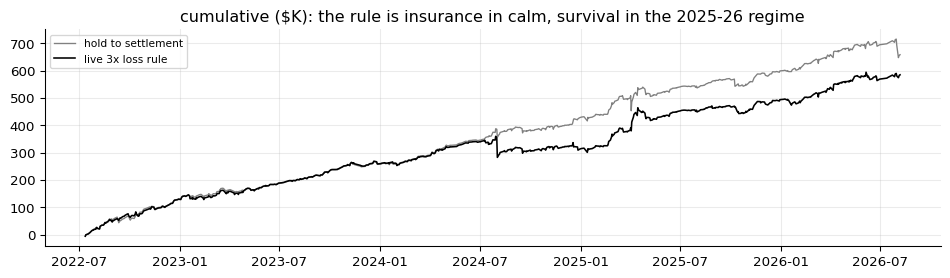

Read: at the structure level the rule transforms the tail (worst -197 -> -118
points; Sharpe 1.65 -> 2.97). At book sizing the regimes split: in the calm era it costs
~0.6 Sharpe of insurance premium; in the 2025-08+ regime it flips to +0.7 with the worst
day cut from -45K to -18K. One caveat shown honestly: on violent V-days a gap-through
fill can buy back near the panic low — loss management, not loss elimination.


In [3]:
t = sx.filter(pl.col('units') != 0)
rows = []
for tag, lo, hi in [('full 2022-07 -> 2026-08', None, None),
                    ('calm era -> 2025-07', None, datetime.date(2025,7,31)),
                    ('recent regime 2025-08 ->', datetime.date(2025,8,1), None)]:
    w = t
    if lo: w = w.filter(pl.col('entry_date') >= lo)
    if hi: w = w.filter(pl.col('entry_date') <= hi)
    for arm in ('pnl_settle_arm', 'pnl_stop3x_arm'):
        x = w[arm].drop_nulls().to_numpy()
        rows.append(dict(window=tag, arm=arm.replace('pnl_','').replace('_arm',''),
                         sharpe=round(sh(x), 2), worst_K=round(x.min()/1e3), n=len(x)))
print(pl.DataFrame(rows))
sd = t.filter(pl.col('units') < 0)
xs, xt = sd['pnl_settle'].to_numpy(), sd['pnl_stop3x'].to_numpy()
print(f"\nper-strangle (points): settle Sharpe {sh(xs):+.2f} worst {xs.min():+.0f} -> "
      f"3x-stop {sh(xt):+.2f} worst {xt.min():+.0f}; triggers "
      f"{int(sd['triggered'].sum())}/{sd.height} short days")
cs = t.select('entry_date', s=pl.col('pnl_settle_arm').cum_sum(),
              x3=pl.col('pnl_stop3x_arm').cum_sum())
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(cs['entry_date'], cs['s']/1e3, 'gray', lw=1.0, label='hold to settlement')
ax.plot(cs['entry_date'], cs['x3']/1e3, 'k', lw=1.2, label='live 3x loss rule')
ax.legend(fontsize=8); ax.set_title('cumulative ($K): the rule is insurance in calm, survival in the 2025-26 regime')
plt.tight_layout(); plt.show()
print("""Read: at the structure level the rule transforms the tail (worst -197 -> -118
points; Sharpe 1.65 -> 2.97). At book sizing the regimes split: in the calm era it costs
~0.6 Sharpe of insurance premium; in the 2025-08+ regime it flips to +0.7 with the worst
day cut from -45K to -18K. One caveat shown honestly: on violent V-days a gap-through
fill can buy back near the panic low — loss management, not loss elimination.""")

## 4. Luck check — is the realized P&L distinguishable from chance?

Two bootstrap questions on the desk config's daily P&L (rules on). First, the **luck
band**: resampling the realized daily returns (stationary block bootstrap, 10,000 paths
of the same length) shows the spread of outcomes this return stream could have delivered
— where the realized total sits in its own band, and how often a path like this loses
money overall. Second, the **zero-edge null**: demean the daily returns (a strategy with
this volatility but NO edge) and ask how often pure luck reaches the realized total —
the p-value for "it's all luck."


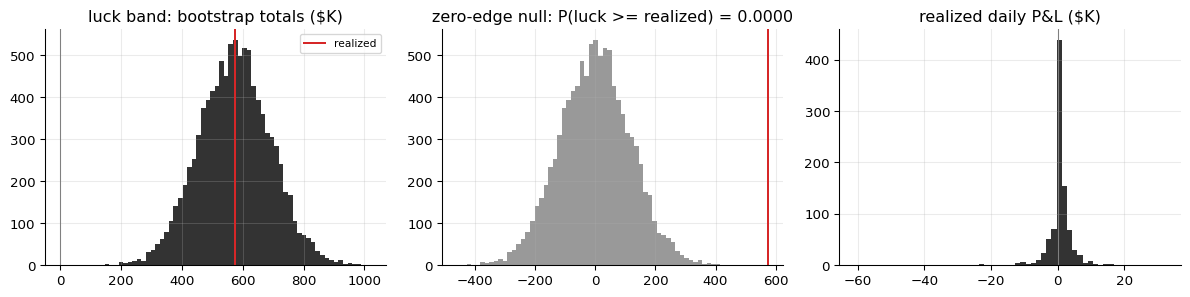

realized total +574K | luck band 5th-95th [+382K, +763K] | P(a path like this loses money) = 0.00%
zero-edge null: P(total >= realized by luck) = 0.0000 (edge is NOT luck at conventional levels)


In [4]:
def block_boot(x, n_boot=10000, mean_block=3, rng=None):
    rng = rng or np.random.default_rng(7)
    n = len(x)
    p = 1.0/mean_block
    tot = np.empty(n_boot)
    for b in range(n_boot):
        idx = np.empty(n, dtype=int)
        i = rng.integers(n)
        for k in range(n):
            idx[k] = i
            i = rng.integers(n) if rng.random() < p else (i + 1) % n
        tot[b] = x[idx].sum()
    return tot

x = desk['pnl_post_rules'].drop_nulls().to_numpy()
real = x.sum()
tot = block_boot(x)
null = block_boot(x - x.mean())
p_luck = float((null >= real).mean())
fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.2))
ax[0].hist(tot/1e3, bins=60, color='k', alpha=0.8)
ax[0].axvline(real/1e3, c='tab:red', lw=1.5, label='realized')
ax[0].axvline(0, c='gray', lw=0.8)
ax[0].legend(fontsize=8); ax[0].set_title('luck band: bootstrap totals ($K)')
ax[1].hist(null/1e3, bins=60, color='gray', alpha=0.8)
ax[1].axvline(real/1e3, c='tab:red', lw=1.5)
ax[1].set_title(f'zero-edge null: P(luck >= realized) = {p_luck:.4f}')
ax[2].hist(x/1e3, bins=60, color='k', alpha=0.8)
ax[2].axvline(0, c='gray', lw=0.8)
ax[2].set_title('realized daily P&L ($K)')
plt.tight_layout(); plt.show()
print(f"realized total {real/1e3:+,.0f}K | luck band 5th-95th "
      f"[{np.percentile(tot,5)/1e3:+,.0f}K, {np.percentile(tot,95)/1e3:+,.0f}K] | "
      f"P(a path like this loses money) = {(tot<0).mean():.2%}")
print(f"zero-edge null: P(total >= realized by luck) = {p_luck:.4f} "
      f"({'edge is NOT luck at conventional levels' if p_luck < 0.01 else 'not separable from luck yet'})")

## 5. Conclusions

- The reversal signal on the 1-DTE straddle's own short-side returns times a real,
  oscillating premium; both configurations clear Sharpe 2 with the production rules on,
  and a year of live trading has tracked the backtest.
- The two position rules (deadband, weekend) add Sharpe on identical inputs — they encode
  live lessons (don't trade conviction-free signals; don't pay multiple days of decay for
  one day of signal).
- The live 3× loss rule is regime insurance: a measurable premium in calm years, decisive
  protection in the 2025-26 regime, with the honest V-day caveat.
- The bootstrap luck check places the realized total well inside its own band and far
  outside the zero-edge null — the P&L is not a draw from luck.

*Private research behind this: the signal construction and parameter provenance, the
management-rule studies (per-leg vs package stops, profit-takes, entry filters, all
pre-registered with a spent holdout), execution/cost analysis, and the cross-book
portfolio work.*